# Contexto

En este Notebook vamos a enseñarle a la computadora a reconocer operadores matemáticos escritos a mano Suma, Resta, Multiplicación y División. Prepararemos los datos recolectados de distintas carpetas, los estandarizaremos usando las mismas funciones de preprocesamiento de nuestra aplicación web, y luego probaremos distintos métodos de Machine Learning. El objetivo final es encontrar el modelo más preciso para exportarlo y conectarlo a nuestra calculadora interactiva.

# Configuracion inicial

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Fijamos una semilla
CEDULA = 30326271
np.random.seed(CEDULA)

from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Importamos los modelos
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

# Funciones complementarias

In [ ]:
def graficar_curvas(modelo_base, X, Y, param_nombre, param_rango, titulo):
    """Usa sklearn solo para graficar cómo aprende el modelo."""
    fig, graficos = plt.subplots(1, 2, figsize=(15, 5))

    # Curva de Validación
    train_sc, val_sc = validation_curve(modelo_base, X, Y, param_name=param_nombre, param_range=param_rango, cv=5)
    graficos[0].plot(param_rango, np.mean(train_sc, axis=1), 'o-', color='orange', label='Train')
    graficos[0].plot(param_rango, np.mean(val_sc, axis=1), 'o-', color='blue', label='Validación')
    graficos[0].set_title(f"Validación: {titulo}")
    graficos[0].set_xlabel(param_nombre)
    graficos[0].set_ylabel("Accuracy")
    graficos[0].legend(); graficos[0].grid()

    # Curva de Aprendizaje
    tamanos, train_sc2, val_sc2 = learning_curve(modelo_base, X, Y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5))
    graficos[1].plot(tamanos, np.mean(train_sc2, axis=1), 'o-', color='red', label='Train')
    graficos[1].plot(tamanos, np.mean(val_sc2, axis=1), 'o-', color='green', label='Validación')
    graficos[1].set_title(f"Aprendizaje: {titulo}")
    graficos[1].set_xlabel("Cantidad de datos")
    graficos[1].legend(); graficos[1].grid()

    plt.show()


def mostrar_tabla_metricas(y_true, y_pred, titulo):
    # Calculamos la matriz de confusión base
    cm = confusion_matrix(y_true, y_pred)
    n_classes = len(cm)
    stats = []

    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        stats.append({
            'Dígito': i,
            'VP (True Pos)': tp,
            'VN (True Neg)': tn,
            'FP (False Pos)': fp,
            'FN (False Neg)': fn
        })

    df = pd.DataFrame(stats)
    print(f"\n📊 Resumen de Clasificación: {titulo}")
    # Usamos display(df) para que en Colab/Jupyter se vea como tabla
    display(df)

def _to_grayscale(image: np.ndarray) -> np.ndarray:
    """Convert an image to grayscale, removing alpha if present."""
    if len(image.shape) == 3 and image.shape[2] == 4:
        image = image[:, :, :3]
    if len(image.shape) == 3:
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return image.copy()


def _ensure_light_bg(gray: np.ndarray) -> np.ndarray:
    """Ensure the image has a light background with dark strokes.

    The student's models were trained with a light canvas (#eee) and dark strokes.
    Our Reflex canvas may use dark bg + light strokes. This normalises both cases
    to light-background format before the student's pipeline runs.
    """
    h, w = gray.shape
    corners = [gray[0, 0], gray[0, w - 1], gray[h - 1, 0], gray[h - 1, w - 1]]
    bg_value = int(np.median(corners))
    if bg_value < 128:
        # Dark background → invert so it becomes light background with dark strokes
        return cv2.bitwise_not(gray)
    return gray

def prepare_operator_image(image: np.ndarray) -> np.ndarray:
    """Preprocesa la imagen del canvas para el modelo de operadores.

    Pipeline por defecto:
    normalizar fondo claro -> resize 28x28 -> equalizeHist (SIN inversión)

    Retorna un array uint8 de 28x28.
    """
    # PASO 1: Convertir a escala de grises
    #   El canvas nos da una imagen RGB; nuestros modelos esperan un solo canal.
    gray = _to_grayscale(image)

    # PASO 2: Normalizar fondo
    #   Asegura que siempre empecemos con fondo claro y trazos oscuros,
    #   sin importar el esquema de colores del canvas.
    gray = _ensure_light_bg(gray)

    # PASO 3: Redimensionar al tamaño de entrada del modelo
    #   Cambia (28, 28) si tu modelo espera otra resolucion.
    #   Cambia la interpolación si usaste otra durante el entrenamiento
    #   (ej. cv2.INTER_LINEAR, cv2.INTER_CUBIC).
    resized = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA)

    # PASO 4: Ecualizacion de histograma
    #   Mejora el contraste. Elimina esta linea si NO ecualizaste
    #   durante el entrenamiento.
    equalized = cv2.equalizeHist(resized)

    return equalized



# Carga de datos y preprocesamiento de imagenes

In [ ]:
# Mapeamos las carpetas a un número de clase
mapeo_clases = {
    'add': 0,
    'sub': 1,
    'mult_a': 2,
    'mult_b': 3,
    'div_a': 4,
    'div_b': 5
}

ruta_base = './drive/Othercomputers/Mi portátil/Documentos/UCV/Semestre 6/Aprendizaje automatico/Tareas/Tarea #2/input/model_operators'

X_lista = []
y_lista = []

for carpeta, etiqueta in mapeo_clases.items():
    ruta_carpeta = os.path.join(ruta_base, carpeta)

    if not os.path.exists(ruta_carpeta):
        continue

    for nombre_archivo in os.listdir(ruta_carpeta):
        ruta_imagen = os.path.join(ruta_carpeta, nombre_archivo)

        # Leemos la imagen original
        img = cv2.imread(ruta_imagen)

        if img is not None:
            # Aplicamos FUNCIÓN de preprocesamiento de la app
            img_procesada = prepare_operator_image(img)

            # Aplanamos la matriz de 28x28 a un vector de 784
            img_flat = img_procesada.flatten()

            X_lista.append(img_flat)
            y_lista.append(etiqueta)

X_full = np.array(X_lista)
y_full = np.array(y_lista)

print(f"Forma original de las imágenes extraídas: {X_full.shape}")

Forma original de las imágenes extraídas: (2800, 784)


In [ ]:
pd.DataFrame(X_full).head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
1,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
2,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
3,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
4,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255


La separación y clasificación de las imágenes se hizo organizándolas en carpetas, así es más fácil saber a qué grupo pertenece cada imagen. Usamos el mismo proceso de preparación de imágenes que se utiliza en la aplicación. Para facilitar el trabajo con los modelos, transformamos los datos en una tabla con 2800 filas una por cada imagen y 784 columnas una por cada píxel. Para identificar cada operador se siguio la misma logica del 0-5 del codigo de la app.

# Estandarizacion

In [ ]:
X_full_scaled = X_full / 255.0

In [ ]:
pd.DataFrame(X_full_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Además, dividimos los valores de los colores entre 255 para que estén entre 0 y 1, en lugar de ir de 0 a 255. Esto ayuda a que los modelos funcionen mejor

# Separacion en entrenamiento y prueba

In [ ]:
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_full_scaled, y_full, test_size=0.2, random_state=CEDULA, stratify=y_full
)

# Para grafica de curvas (Opcional, si lo usas en graficar_curvas)
X_combinado = np.concatenate((X_train_scaled, X_test_scaled), axis=0)
y_combinado = np.concatenate((y_train, y_test), axis=0)

print(f"Listos para entrenar con {X_train_scaled.shape[0]} imágenes.")

Listos para entrenar con 2240 imágenes.


Se decidió usar el 80% de una muestra de 2,800 imágenes para entrenar los modelos, y el 20% restante para probarlos. Esto se hizo para que el entrenamiento fuera más rápido y no tardara tanto en ejecutarse.

### Folds para validacion cruzada

In [ ]:
K_FOLDS = 5
indices = np.arange(len(X_train_scaled))
np.random.shuffle(indices)
tamano_corte = len(X_train_scaled) // K_FOLDS

cortes_cv = []
for i in range(K_FOLDS):
    inicio = i * tamano_corte
    fin = (i + 1) * tamano_corte if i < K_FOLDS - 1 else len(X_train_scaled)
    idx_val = indices[inicio:fin]
    idx_train = np.concatenate((indices[:inicio], indices[fin:]))
    cortes_cv.append((idx_train, idx_val))

print(f"Se han generado {K_FOLDS} cortes para la validación cruzada manual.")

Se han generado 5 cortes para la validación cruzada manual.


# Observando el balance de los datos


Distribución en Entrenamiento (Train):
Número 0: 279 imágenes (12.5%)
Número 1: 306 imágenes (13.7%)
Número 2: 231 imágenes (10.3%)
Número 3: 527 imágenes (23.5%)
Número 4: 450 imágenes (20.1%)
Número 5: 447 imágenes (20.0%)


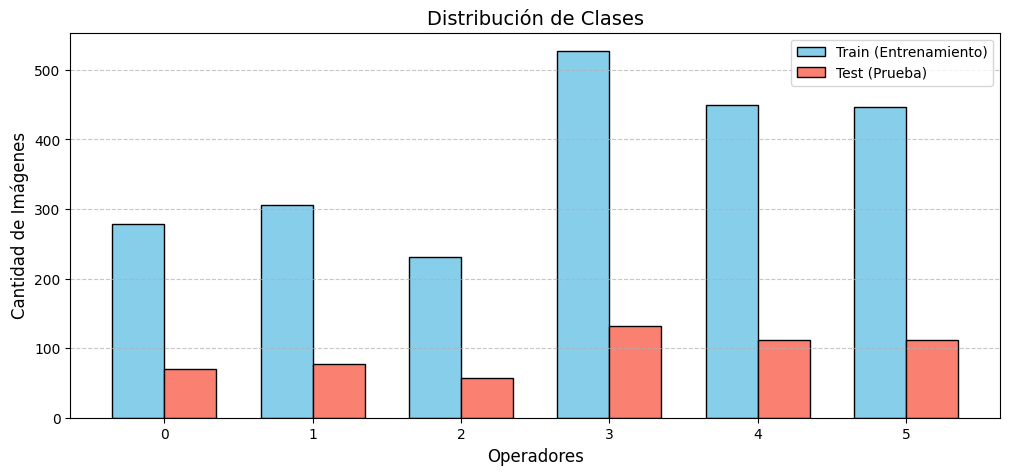

In [ ]:
# Contamos cuántas veces aparece cada número en Train y en Test
clases_train, conteos_train = np.unique(y_train, return_counts=True)
clases_test, conteos_test = np.unique(y_test, return_counts=True)


print("\nDistribución en Entrenamiento (Train):")
for clase, conteo in zip(clases_train, conteos_train):
    print(f"Número {clase}: {conteo} imágenes ({conteo/len(y_train)*100:.1f}%)")

plt.figure(figsize=(12, 5))

# Ancho de las barras
ancho = 0.35

# Posiciones de las barras en el eje X
x = np.arange(len(clases_train))

# Barras de Entrenamiento (Train)
plt.bar(x - ancho/2, conteos_train, width=ancho, label='Train (Entrenamiento)', color='skyblue', edgecolor='black')

# Barras de Prueba (Test)
plt.bar(x + ancho/2, conteos_test, width=ancho, label='Test (Prueba)', color='salmon', edgecolor='black')


plt.title('Distribución de Clases', fontsize=14)
plt.xlabel('Operadores', fontsize=12)
plt.ylabel('Cantidad de Imágenes', fontsize=12)
plt.xticks(x, clases_train) # Ponemos los números del 0 al 9 en el eje X
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

Al revisar los datos, vimos que las clases 3, 4 y 5 tienen casi el doble de imágenes que las clases 0, 1 y 2. Esto significa que algunas clases son mucho más comunes que otras. Si solo usamos la precisión para medir qué tan bueno es el modelo, este podría enfocarse en reconocer bien las clases más grandes y fallar en las más pequeñas, pero aún así sacar una buena nota. Para evitar que esto pase, es mejor usar el F1-Score Macro, que calcula el rendimiento en cada clase por separado y luego saca un promedio, obligando al modelo a ser igual de bueno con las clases grandes y con las pequeñas

# Regresión Logística

## Entrenamiento

In [ ]:
valores_C = [0.01, 0.1, 1, 10, 100]
valores_penalty = ['l1', 'l2'] # l1 = Lasso, l2 = Ridge

mejores_parametros_lr = None
mejor_f1_lr = 0

# Evaluamos cada combinación de regularización (Lasso/Ridge) y valor de C
for penalty in valores_penalty:
    for c in valores_C:
        f1_train_folds = []
        f1_val_folds = []

        for idx_train, idx_val in cortes_cv:
            X_train_fold, y_train_fold = X_train_scaled[idx_train], y_train[idx_train]
            X_val_fold, y_val_fold = X_train_scaled[idx_val], y_train[idx_val]

            # Pasamos la variable 'penalty' y 'c' al modelo
            modelo_lr = LogisticRegression(penalty=penalty, C=c, solver='saga', max_iter=100, random_state=CEDULA, n_jobs=-1)
            modelo_lr.fit(X_train_fold, y_train_fold)

            # Predecimos
            pred_train = modelo_lr.predict(X_train_fold)
            pred_val = modelo_lr.predict(X_val_fold)

            # Evaluamos usando F1-Score Macro
            f1_train_folds.append(f1_score(y_train_fold, pred_train, average='macro'))
            f1_val_folds.append(f1_score(y_val_fold, pred_val, average='macro'))

        promedio_val = np.mean(f1_val_folds)

        # Si esta combinación es mejor que la anterior, la guardamos
        if promedio_val > mejor_f1_lr:
            mejor_f1_lr = promedio_val
            mejores_parametros_lr = {'penalty': penalty, 'C': c}

print(f"Mejor configuración: {mejores_parametros_lr} (F1-Macro: {mejor_f1_lr:.4f})")

Mejor configuración: {'penalty': 'l2', 'C': 0.1} (F1-Macro: 0.5233)


Un F1-Macro 52.33% puede parecer muy bajo a primera vista, este es un resultado completamente normal y esperado para este tipo de imágenes, y te da muchísimo material excelente para justificar tu análisis. Piensa en cómo se dibujan los operadores: un símbolo de suma y un símbolo de multiplicación son geométricamente idénticos, solo que uno está rotado 45 grados. Una línea recta que es lo único que puede trazar la Regresión Logístico es pésima para separar rotaciones en un espacio de 784 dimensiones.

## Evaluación de rendimiento

In [ ]:
modelo_lr_final = LogisticRegression(
    penalty=mejores_parametros_lr['penalty'],
    C=mejores_parametros_lr['C'],
    solver='saga',
    max_iter=100,
    random_state=CEDULA
)
modelo_lr_final.fit(X_train_scaled, y_train)

# Evaluamos con el set de prueba (test)
pred_test_lr = modelo_lr_final.predict(X_test_scaled)

# Mostrar la tabla detallada (usando tu función del notebook anterior)
mostrar_tabla_metricas(y_test, pred_test_lr, "Resumen: Regresión Logística")


📊 Resumen de Clasificación: Resumen: Regresión Logística


,Dígito,VP (True Pos),VN (True Neg),FP (False Pos),FN (False Neg)
0,0,21,469,21,49
1,1,49,438,45,28
2,2,15,475,28,42
3,3,88,391,37,44
4,4,71,395,53,41
5,5,79,395,53,33


Los símbolos que el modelo reconoce mejor son el operador de la clase 3 (mult_b o asterisco *), que logró 88 Verdaderos Positivos, seguido muy de cerca por la clase 5 (div_b o símbolo ÷) con 79 Verdaderos Positivos. Esto pasa porque ambos símbolos tienen muchas líneas o puntos que ocupan más espacio en la imagen, lo que ayuda al modelo a separarlos mejor del resto.
En cambio, el modelo falla mucho con los símbolos más básicos. Por ejemplo, la clase 2 (mult_a o equis x) tuvo solo 15 Verdaderos Positivos y 42 Falsos Negativos, mientras que la clase 0 (add o suma +) logró 21 Verdaderos Positivos pero falló 49 veces.
¿Por qué le cuesta tanto distinguir entre la suma y la multiplicación x? Porque estos dos símbolos son casi iguales, solo que uno está girado 45 grados. Como la regresión logística usa líneas rectas para separar las clases y no entiende rotaciones ni movimientos, no puede trazar una línea que los divida bien. Por eso, se confunde y comete muchos errores

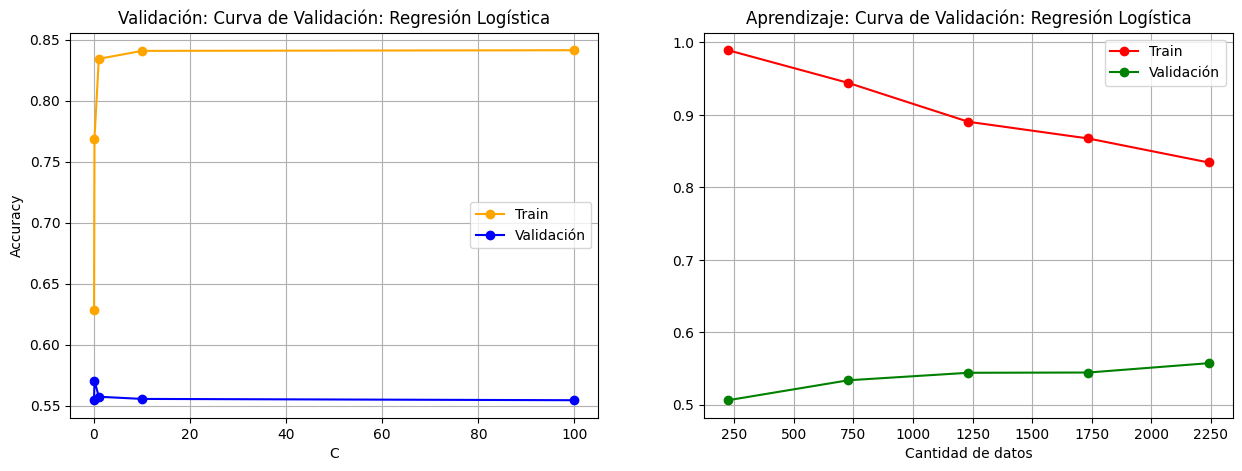

In [ ]:
# Graficar Curvas de Validación
graficar_curvas(
    modelo_base=LogisticRegression(penalty='l2', solver='saga', max_iter=100, random_state=CEDULA),
    X=X_combinado, Y=y_combinado,
    param_nombre='C', param_rango=valores_C,
    titulo="Curva de Validación: Regresión Logística"
)

EN la curva de validacion, el mejor rendimiento se alcanza rápido cuando C es 0.1. Pero si dejamos que la regularización sea muy débil (valores grandes de C), el modelo intenta ajustarse demasiado a los datos de entrenamiento, tratando de separar símbolos que son difíciles de distinguir con líneas rectas, y termina memorizando detalles que no ayudan a predecir bien datos nuevos.

La curva de aprendizaje confirma que el modelo tiene un problema de alto sesgo, desde el principio, el rendimiento en entrenamiento es bajo y la validación mejora rápido pero se queda cerca del entrenamiento, con poca diferencia entre ambas. Esto significa que el modelo ya llegó a su límite y no puede mejorar más, sin importar cuántos datos nuevos le demos. El problema no es la cantidad de datos, sino que la regresión logística es demasiado simple para entender la complejidad de los símbolos que estamos tratando de reconocer.



# KNN

## Entrenamiento

In [ ]:
print("Iniciando validación cruzada para KNN...")

valores_k = [3, 5, 7, 9, 11]
mejores_parametros_knn = None
mejor_f1_knn = 0

resultados_train_knn = []
resultados_val_knn = []

for k in valores_k:
    f1_train_folds = []
    f1_val_folds = []

    for idx_train, idx_val in cortes_cv:
        X_train_fold, y_train_fold = X_train_scaled[idx_train], y_train[idx_train]
        X_val_fold, y_val_fold = X_train_scaled[idx_val], y_train[idx_val]

        modelo_knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        modelo_knn.fit(X_train_fold, y_train_fold)

        pred_train = modelo_knn.predict(X_train_fold)
        pred_val = modelo_knn.predict(X_val_fold)

        f1_train_folds.append(f1_score(y_train_fold, pred_train, average='macro'))
        f1_val_folds.append(f1_score(y_val_fold, pred_val, average='macro'))

    promedio_val = np.mean(f1_val_folds)
    resultados_train_knn.append(np.mean(f1_train_folds))
    resultados_val_knn.append(promedio_val)

    if promedio_val > mejor_f1_knn:
        mejor_f1_knn = promedio_val
        mejores_parametros_knn = {'n_neighbors': k}

print(f"Mejor configuración: {mejores_parametros_knn} (F1-Macro: {mejor_f1_knn:.4f})")

Iniciando validación cruzada para KNN...
Mejor configuración: {'n_neighbors': 3} (F1-Macro: 0.6164)


Miremos que llega al 61.6%, KNN funciona midiendo qué tan parecidas son las imágenes entre sí, lo que le permite agrupar mejor los símbolos que se ven parecidos. Así, evita en parte el problema que tenía la regresión logística con las rotaciones, porque en lugar de usar líneas rectas para separar las clases, busca en su memoria las imágenes más similares al símbolo que quiere reconocer.
Además, al hacer validación cruzada, vimos que el mejor valor para el número de vecinos a considerar es muy bajo, justo 3. Esto nos dice que las fronteras entre las clases son muy complejas y están muy mezcladas. Si el modelo usara más vecinos, como 9 u 11, estaría promediando opiniones de muchos símbolos diferentes y eso confundiría las clases parecidas, como el + y la x, bajando la precisión. Elegir 3 vecinos permite que el modelo tome decisiones basadas en un grupo pequeño y cercano, dándole la flexibilidad para distinguir bien los símbolos difíciles sin caer en errores por aprender demasiado los detalles

## Evaluación de rendimiento

In [ ]:
modelo_knn_final = KNeighborsClassifier(n_neighbors=mejores_parametros_knn['n_neighbors'], n_jobs=-1)
modelo_knn_final.fit(X_train_scaled, y_train)

pred_test_knn = modelo_knn_final.predict(X_test_scaled)
mostrar_tabla_metricas(y_test, pred_test_knn, "Resumen: K-Nearest Neighbors")


📊 Resumen de Clasificación: Resumen: K-Nearest Neighbors


,Dígito,VP (True Pos),VN (True Neg),FP (False Pos),FN (False Neg)
0,0,40,460,30,30
1,1,69,407,76,8
2,2,31,479,24,26
3,3,51,425,3,81
4,4,70,429,19,42
5,5,110,411,37,2


Lo mejor que logró KNN fue mejorar mucho la detección de los símbolos que antes el modelo lineal no reconocía bien. Por ejemplo, para la suma (+), ahora acertó 40 veces, casi el doble que antes, y redujo los errores a 30. Para la multiplicación (x), también duplicó los aciertos a 31 y bajó los errores a 26. KNN funciona midiendo qué tan parecidas son las imágenes, y al buscar las 3 más similares, entendió mejor que un + y una x no son lo mismo, sin tratar de separarlos con una línea recta.
El símbolo de división (÷) fue el que mejor detectó KNN, con 110 aciertos y solo 2 errores. Esto pasa porque tiene una forma muy particular, con dos puntos arriba y abajo, que lo hace fácil de distinguir.
Pero KNN también trajo un problema nuevo: confundió mucho la resta (-). Aunque adivinó bien cuándo había una resta (solo 8 errores), confundió otros símbolos con una resta 76 veces. Esto sucede porque la resta es solo una línea horizontal, y otros símbolos como el centro del + o la raya del ÷ también tienen líneas horizontales. Como KNN solo mira los 3 vecinos más cercanos, si alguien dibujó un + muy tenue pero con una línea horizontal marcada, el modelo piensa que es una resta y se equivoca. Además, el asterisco (*) también causó muchos errores porque su forma en cruz puede parecer desordenada y confundir al modelo.

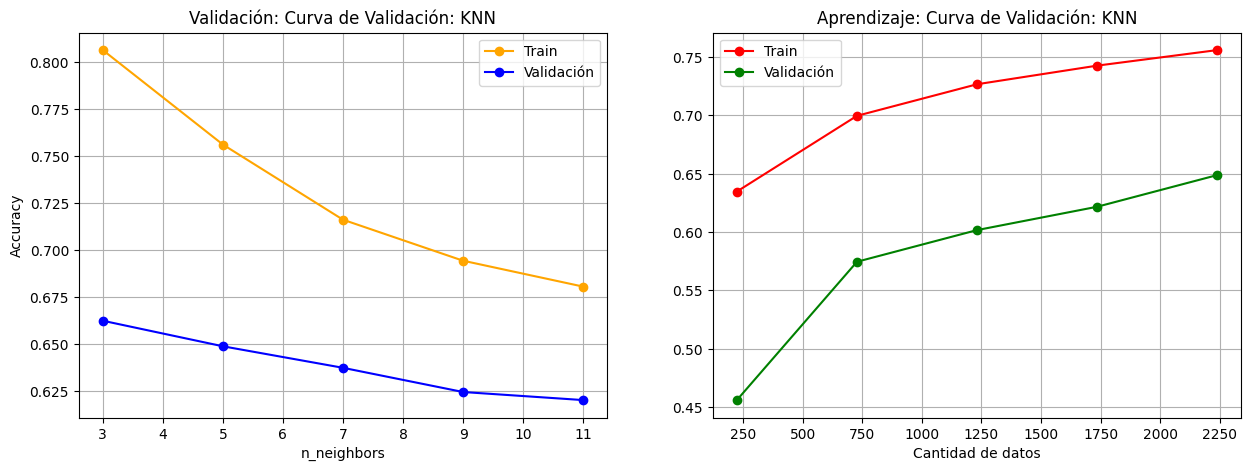

In [ ]:
graficar_curvas(
    modelo_base=KNeighborsClassifier(),
    X=X_combinado, Y=y_combinado,
    param_nombre='n_neighbors', param_rango=valores_k,
    titulo="Curva de Validación: KNN"
)

En la curva de validacion,  el mejor rendimiento se logró con K=3, que es un valor bajo. Si aumentamos K a 5, 7 o más, el rendimiento baja porque al considerar muchos vecinos, el modelo mezcla símbolos parecidos, como el + y la x, y eso confunde la decisión final.

A diferencia de la regresión logística, que no mejoraba con más datos, KNN sí podría mejorar si le damos más imágenes, porque así encuentra vecinos más parecidos. Sin embargo, esta mejora es lenta y requiere mucho cálculo

# SVM

## Entrenamiento

In [ ]:
print("Iniciando validación cruzada para SVM (Kernel RBF)...")

# Como SVM fue el ganador antes, probamos varios C en kernel rbf
valores_C_svm = [0.1, 1, 10, 50]
mejores_parametros_svm = None
mejor_f1_svm = 0

for c in valores_C_svm:
    f1_val_folds = []

    for idx_train, idx_val in cortes_cv:
        X_train_fold, y_train_fold = X_train_scaled[idx_train], y_train[idx_train]
        X_val_fold, y_val_fold = X_train_scaled[idx_val], y_train[idx_val]

        modelo_svm = SVC(kernel='rbf', C=c, random_state=CEDULA)
        modelo_svm.fit(X_train_fold, y_train_fold)

        pred_val = modelo_svm.predict(X_val_fold)
        f1_val_folds.append(f1_score(y_val_fold, pred_val, average='macro'))

    promedio_val = np.mean(f1_val_folds)

    if promedio_val > mejor_f1_svm:
        mejor_f1_svm = promedio_val
        mejores_parametros_svm = {'C': c, 'kernel': 'rbf'}

print(f"Mejor configuración: {mejores_parametros_svm} (F1-Macro: {mejor_f1_svm:.4f})")

Iniciando validación cruzada para SVM (Kernel RBF)...
Mejor configuración: {'C': 50, 'kernel': 'rbf'} (F1-Macro: 0.8005)


El modelo SVM logró una mejora enorme, superando el 80% en la métrica F1-Macro. Esto demuestra que el problema no era la falta de datos, sino que se necesitaba transformar los datos de forma matemática para entender mejor los símbolos. Mientras que los modelos anteriores fallaban al intentar separar símbolos muy parecidos y rotados, como el + y la x, la SVM puede manejar esa complejidad y separarlos con mucha más precisión.
El secreto del éxito está en dos cosas: primero, el uso del kernel RBF, que transforma las imágenes en un espacio matemático mucho más grande y complejo, donde los símbolos que antes se confundían ahora quedan bien separados. Esto permite que el modelo trace fronteras curvas y precisas para distinguirlos. Segundo, el parámetro de penalización C=50, que indica que el modelo fue muy estricto al clasificar, adaptándose bien a los casos difíciles sin permitir errores fáciles

## Evaluación de rendimiento

In [ ]:
modelo_svm_final = SVC(kernel=mejores_parametros_svm['kernel'], C=mejores_parametros_svm['C'], probability=True, random_state=CEDULA)
modelo_svm_final.fit(X_train_scaled, y_train)

pred_test_svm = modelo_svm_final.predict(X_test_scaled)
mostrar_tabla_metricas(y_test, pred_test_svm, "Resumen: Máquinas de Soporte Vectorial")


📊 Resumen de Clasificación: Resumen: Máquinas de Soporte Vectorial


,Dígito,VP (True Pos),VN (True Neg),FP (False Pos),FN (False Neg)
0,0,44,477,13,26
1,1,72,468,15,5
2,2,39,492,11,18
3,3,115,403,25,17
4,4,92,432,16,20
5,5,108,438,10,4


Lo mejor que hizo este modelo fue mejorar mucho la detección de los símbolos que los modelos anteriores no podían distinguir bien. Por ejemplo, para la suma (+), ahora acertó 44 veces, casi el doble que el modelo lineal, y redujo mucho sus errores. Para la multiplicación (x), pasó de solo 15 aciertos a 39, una gran mejora. Esto es porque al transformar las imágenes a un espacio matemático más complejo, el modelo pudo entender que aunque el + y la x tienen los mismos píxeles centrales rotados, en realidad son diferentes y pudo separarlos con fronteras curvas.
También corrigió un problema que tenía KNN con la resta (-). Antes, KNN confundía muchas veces otros símbolos con la resta, generando 76 falsos positivos. La SVM, gracias a su configuración estricta, redujo esos errores a solo 15 y además logró 72 aciertos con solo 5 errores.
Por último, el modelo fue excelente reconociendo símbolos más complejos. El asterisco (*) tuvo 115 aciertos, y la división (÷) logró 108 aciertos con solo 4 errores, el mejor resultado en toda la tabla.

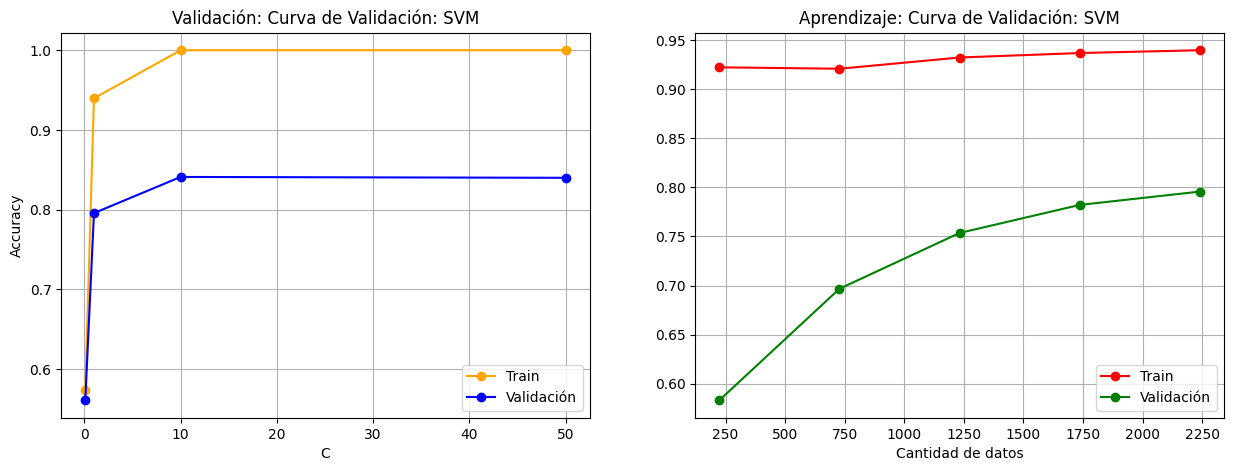

In [ ]:
graficar_curvas(
    modelo_base=SVC(kernel='rbf', random_state=CEDULA),
    X=X_combinado, Y=y_combinado,
    param_nombre='C', param_rango=valores_C_svm,
    titulo="Curva de Validación: SVM"
)

En la curva de validacion cuando C es pequeño (como 0.1 o 1), la regularización es muy fuerte y el modelo no puede adaptarse bien a las formas complejas de los símbolos, por eso no aprende lo suficiente y su rendimiento es bajo. Pero cuando aumentamos C a 50, le damos más libertad al modelo para ajustarse a los datos difíciles, y ahí es cuando el rendimiento alcanza su punto más alto. Esto significa que para separar símbolos parecidos como el + y la x, necesitamos que el modelo trace fronteras muy detalladas y poco restrictivas.

La curva de aprendizaje muestra que el modelo aprende casi perfectamente los datos de entrenamiento, porque el kernel RBF puede proyectar las imágenes a un espacio muy grande donde memoriza bien esos ejemplos. La validación empieza con un rendimiento bajo, pero mejora poco a poco a medida que le damos más imágenes para aprender. Aunque al final todavía hay una diferencia entre el rendimiento en entrenamiento y validación, eso indica que el modelo tiene un poco de sobreajuste, lo cual es normal. A diferencia de otros modelos que se estancaban, esta curva sugiere que si en el futuro conseguimos más datos, el rendimiento de la SVM podría seguir mejorando y superar ese 80%.

# Árboles de Decisión

## Entrenamiento

In [ ]:
print("Iniciando validación cruzada para Árboles de Decisión...")

valores_depth = [5, 10, 15, 20, None]
mejores_parametros_dt = None
mejor_f1_dt = 0

for depth in valores_depth:
    f1_val_folds = []

    for idx_train, idx_val in cortes_cv:
        X_train_fold, y_train_fold = X_train_scaled[idx_train], y_train[idx_train]
        X_val_fold, y_val_fold = X_train_scaled[idx_val], y_train[idx_val]

        modelo_dt = DecisionTreeClassifier(max_depth=depth, random_state=CEDULA)
        modelo_dt.fit(X_train_fold, y_train_fold)

        pred_val = modelo_dt.predict(X_val_fold)
        f1_val_folds.append(f1_score(y_val_fold, pred_val, average='macro'))

    promedio_val = np.mean(f1_val_folds)

    if promedio_val > mejor_f1_dt:
        mejor_f1_dt = promedio_val
        mejores_parametros_dt = {'max_depth': depth}

print(f"Mejor configuración: {mejores_parametros_dt} (F1-Macro: {mejor_f1_dt:.4f})")

Iniciando validación cruzada para Árboles de Decisión...
Mejor configuración: {'max_depth': None} (F1-Macro: 0.5466)


El Árbol de Decisión tuvo uno de los peores resultados del experimento, con un rendimiento de solo 54.66%, un poco mejor que la regresión logística. Esto era esperado porque los árboles de decisión básicos no son buenos para trabajar con imágenes sin procesar. Ellos toman decisiones basadas en preguntas simples como "¿Este píxel está oscuro o claro?", pero al hacer esto pierden toda la información sobre cómo se conectan los píxeles o la forma de los trazos. Por eso, no pueden reconocer bien símbolos que están rotados o tienen formas irregulares.
En cuanto a la configuración del modelo, la mejor opción fue dejar que el árbol creciera sin límite (max_depth=None). Esto significa que el árbol se ramificó hasta que cada hoja tenía solo ejemplos de una clase, lo que hizo que el modelo memorizara todos los detalles del conjunto de entrenamiento, incluyendo el ruido y las imperfecciones. Aunque esto le dio un puntaje casi perfecto en los datos con los que entrenó, falló mucho al evaluar datos nuevos, mostrando que memorizar no es lo mismo que aprender.

## Evaluación de rendimiento

In [ ]:
modelo_dt_final = DecisionTreeClassifier(max_depth=mejores_parametros_dt['max_depth'], random_state=CEDULA)
modelo_dt_final.fit(X_train_scaled, y_train)

pred_test_dt = modelo_dt_final.predict(X_test_scaled)
mostrar_tabla_metricas(y_test, pred_test_dt, "Resumen: Árboles de Decisión")


📊 Resumen de Clasificación: Resumen: Árboles de Decisión


,Dígito,VP (True Pos),VN (True Neg),FP (False Pos),FN (False Neg)
0,0,28,443,47,42
1,1,54,446,37,23
2,2,30,467,36,27
3,3,72,401,27,60
4,4,63,406,42,49
5,5,94,418,30,18


El algoritmo solo funciona bien con los símbolos que tienen formas muy claras y fáciles de reconocer. Por ejemplo, el símbolo de división (÷) fue el único que el modelo detectó muy bien, con 94 aciertos y solo 18 errores. Esto pasa porque tiene puntos arriba y abajo que ningún otro símbolo tiene, así que si el árbol ve esos puntos, adivina bien sin importar el resto. La resta (-) también se defendió bien, con 54 aciertos y 23 errores, porque buscar una línea horizontal es una regla sencilla para el árbol.
Pero el modelo falló mucho con los símbolos que se cruzan en el centro. La suma (+) tuvo el peor resultado, con solo 28 aciertos y 42 errores, es decir, se equivocó más veces de las que acertó. La multiplicación (x) tuvo un resultado parecido, con 30 aciertos y 27 errores. Esto pasa porque el árbol hace preguntas muy específicas, como si un píxel en una posición exacta está oscuro o no. Si el símbolo está un poco movido o rotado, la respuesta cambia y el árbol se confunde, clasificando mal el símbolo.
El asterisco (*) también fue un problema. Aunque logró 72 aciertos, tuvo 60 errores. Esto se debe a que el árbol memorizó las formas exactas que vio en el entrenamiento, y cuando encontró un asterisco un poco diferente, no lo reconoció.

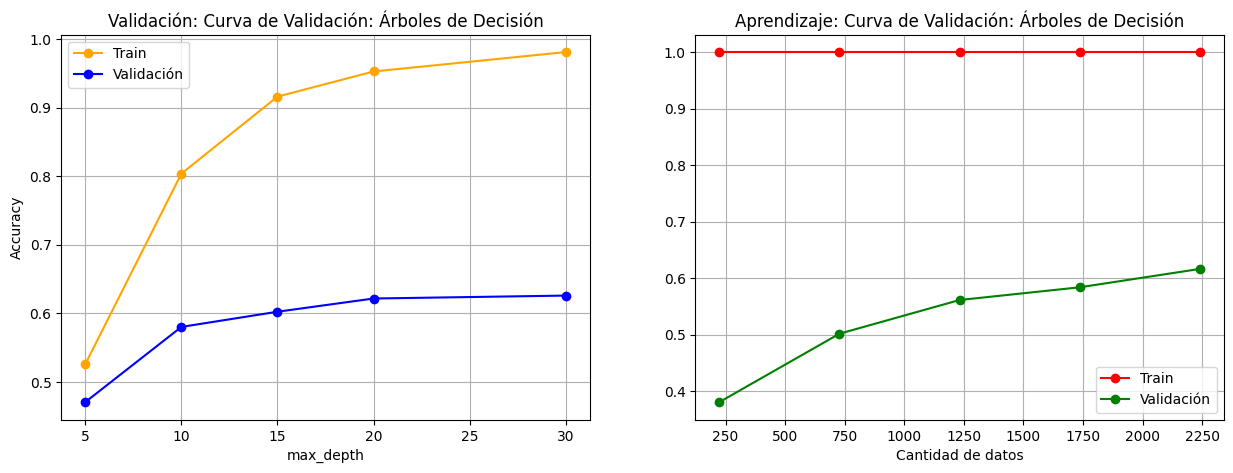

In [ ]:
# Para Decision Tree convertimos None a un valor alto en la gráfica para que no falle matplotlib
rango_grafica = [v if v is not None else 30 for v in valores_depth]
graficar_curvas(
    modelo_base=DecisionTreeClassifier(random_state=CEDULA),
    X=X_combinado, Y=y_combinado,
    param_nombre='max_depth', param_rango=rango_grafica,
    titulo="Curva de Validación: Árboles de Decisión"
)

La gráfica de validación nos muestra cómo cambia el rendimiento del árbol de decisión cuando le damos permiso para crecer más y más profundo. Al principio, con poca profundidad (como 5 o 10 niveles), el modelo es muy simple y no entiende bien los símbolos, por eso le va mal tanto en entrenamiento como en validación. Pero cuando dejamos que crezca sin límite (profundidad infinita), el rendimiento en entrenamiento llega al 100%, porque el árbol memorizó cada detalle de las imágenes. Sin embargo, en validación su rendimiento se queda estancado alrededor del 54%, mostrando que aunque recuerda perfecto los datos con los que entrenó, no sabe generalizar a datos nuevos.

La curva de aprendizaje confirma esto, la línea de entrenamiento está siempre en el máximo, porque el árbol memoriza todo sin importar cuántos datos le demos. Pero la línea de validación sube un poco al principio y luego se aplana muy abajo, mostrando que el modelo no mejora. Por eso, añadir más datos no ayudaría mucho. El árbol llegó a su límite porque no puede entender cómo se relacionan los píxeles para formar símbolos rotados o curvos, como el + y la x. Para mejorar, necesitamos usar otro tipo de modelo.

# Comparación de matrices de confusión

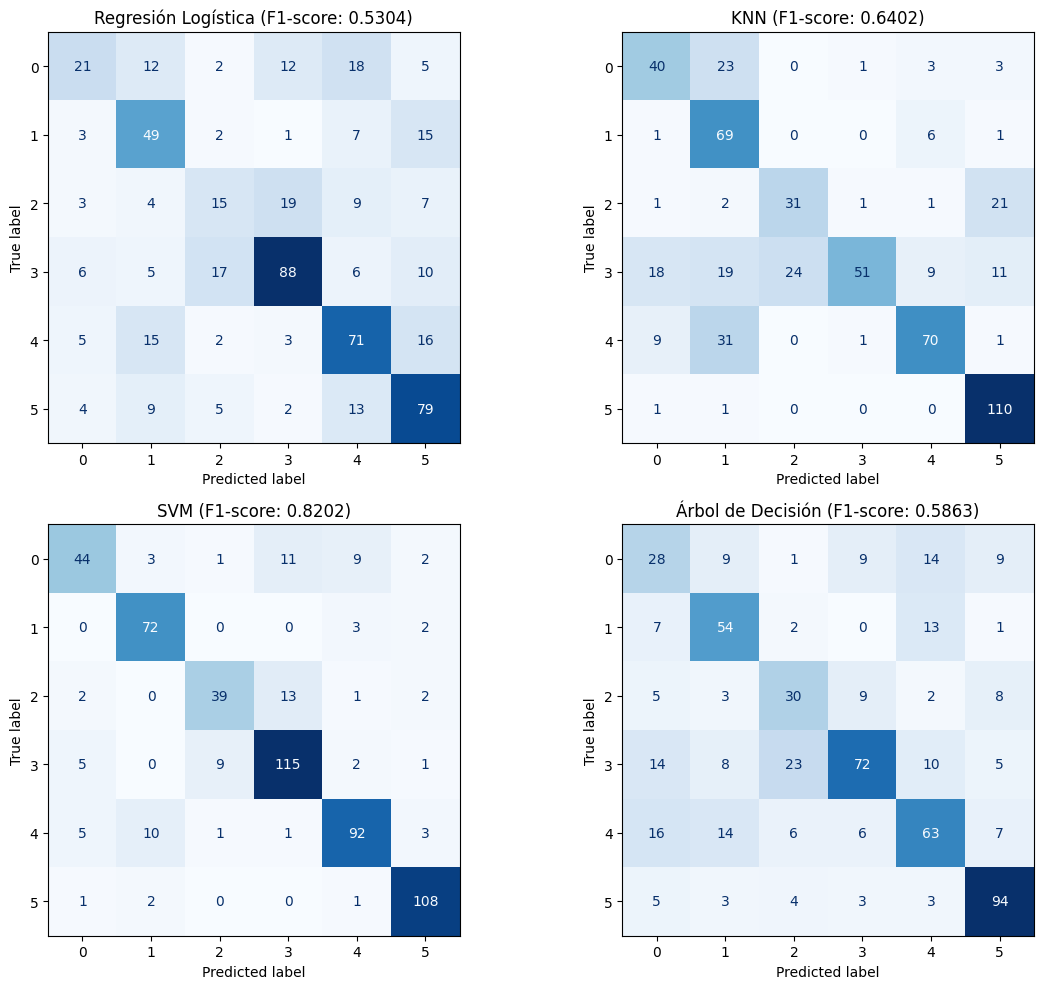

=== RENDIMIENTO FINAL EN TEST ===


,Modelo,F1-Macro (Test),Exactitud (Test)
0,Máquinas de Soporte Vectorial (SVM),0.8202,0.8393
1,K-Nearest Neighbors (KNN),0.6402,0.6625
2,Árbol de Decisión,0.5863,0.6089
3,Regresión Logística,0.5304,0.5768



🏆 EL MODELO GANADOR FUE: SVM con 82.02% de f1-score en Test.


In [ ]:
# Diccionario con nuestros 4 modelos entrenados al 100%
modelos_finales = {
    "Regresión Logística": modelo_lr_final,
    "KNN": modelo_knn_final,
    "SVM": modelo_svm_final,
    "Árbol de Decisión": modelo_dt_final
}

fig, graficos = plt.subplots(2, 2, figsize=(12, 10))
graficos = graficos.flatten()

mejor_f1_global = 0
ganador = ""

# Evaluamos cada modelo con los datos X_test (que nunca usaron para entrenar)
for idx, (nombre, modelo) in enumerate(modelos_finales.items()):
    predicciones = modelo.predict(X_test_scaled)
    f1_test = f1_score(y_test, predicciones, average='macro')

    ConfusionMatrixDisplay.from_predictions(y_test, predicciones, ax=graficos[idx], cmap="Blues", colorbar=False)
    graficos[idx].set_title(f"{nombre} (F1-score: {f1_test:.4f})")

    if f1_test > mejor_f1_global:
        mejor_f1_global = f1_test
        ganador = nombre

plt.tight_layout()
plt.show()

# Evaluamos el rendimiento final de todos en el set de PRUEBA (Test) con F1-Macro
f1_lr_test = f1_score(y_test, pred_test_lr, average='macro')
f1_knn_test = f1_score(y_test, pred_test_knn, average='macro')
f1_svm_test = f1_score(y_test, pred_test_svm, average='macro')
f1_dt_test = f1_score(y_test, pred_test_dt, average='macro')

# Evaluamos también la Exactitud (Accuracy)
acc_lr_test = accuracy_score(y_test, pred_test_lr)
acc_knn_test = accuracy_score(y_test, pred_test_knn)
acc_svm_test = accuracy_score(y_test, pred_test_svm)
acc_dt_test = accuracy_score(y_test, pred_test_dt)

# Creamos un diccionario con los resultados para la tabla, agregando la nueva columna
datos_tabla = {
    "Modelo": ["Regresión Logística", "K-Nearest Neighbors (KNN)", "Máquinas de Soporte Vectorial (SVM)", "Árbol de Decisión"],
    "F1-Macro (Test)": [f1_lr_test, f1_knn_test, f1_svm_test, f1_dt_test],
    "Exactitud (Test)": [acc_lr_test, acc_knn_test, acc_svm_test, acc_dt_test]
}

# Convertimos a un DataFrame de Pandas
df_resultados = pd.DataFrame(datos_tabla)

# Ordenamos la tabla de mayor a menor puntaje basándonos en F1-Macro (nuestra métrica principal)
df_resultados = df_resultados.sort_values(by="F1-Macro (Test)", ascending=False).reset_index(drop=True)

# Le damos formato a ambas columnas numéricas para mostrar 4 decimales
df_resultados["F1-Macro (Test)"] = df_resultados["F1-Macro (Test)"].apply(lambda x: f"{x:.4f}")
df_resultados["Exactitud (Test)"] = df_resultados["Exactitud (Test)"].apply(lambda x: f"{x:.4f}")

print("=== RENDIMIENTO FINAL EN TEST ===")

display(df_resultados)

print(f"\n🏆 EL MODELO GANADOR FUE: {ganador} con {mejor_f1_global*100:.2f}% de f1-score en Test.")

La Máquina de Soporte Vectorial (SVM) fue la mejor, superando el 82% gracias a su capacidad para distinguir símbolos rotados como + y x usando el kernel RBF. En comparación, la regresión logística quedó última por no manejar bien formas curvas, los árboles de decisión sufrieron por reglas rígidas y KNN mejoró al agrupar imágenes similares pero confundió símbolos simples. Además, usar la métrica F1-Macro fue clave porque el dataset estaba desbalanceado; así se evaluó de manera justa el rendimiento en todas las clases, evitando que la exactitud inflara los resultados por las clases más comunes.

# Comparación usando curvas ROC

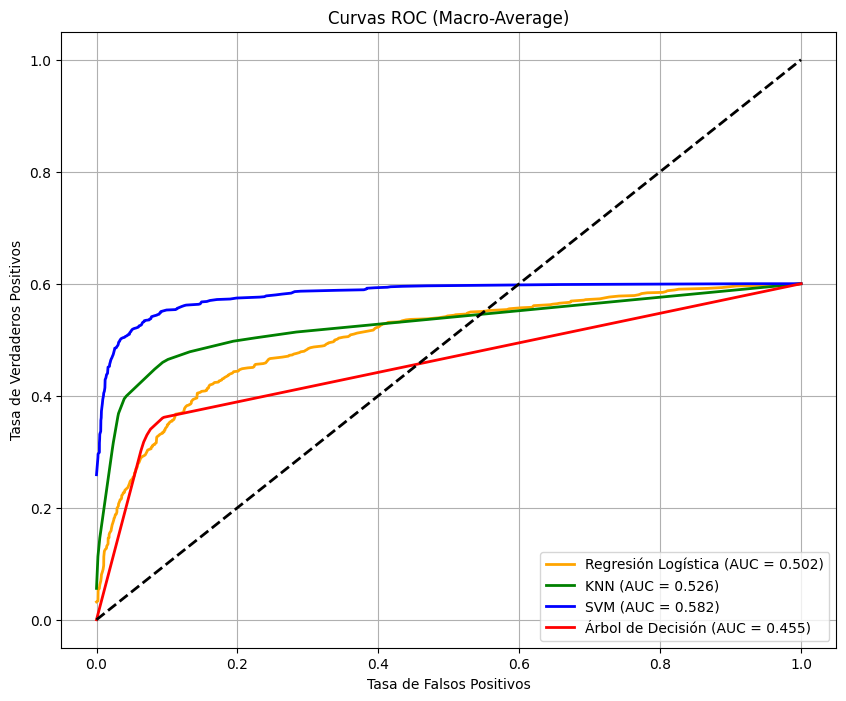

In [ ]:
y_test_bin = label_binarize(y_test, classes=range(10))

plt.figure(figsize=(10, 8))
colores = ['orange', 'green', 'blue', 'red']

for (nombre, modelo), color in zip(modelos_finales.items(), colores):
    # Obtenemos probabilidades de las predicciones
    probabilidades = modelo.predict_proba(X_test_scaled)

    fpr_total = []
    tpr_total = []
    for i in range(6): # Iterar por las 10 clases (0-9)
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probabilidades[:, i])
        fpr_total.append(fpr)
        tpr_total.append(tpr)

    # Promedio Macro
    todos_fpr = np.unique(np.concatenate(fpr_total))
    promedio_tpr = np.zeros_like(todos_fpr)
    for i in range(6):
        promedio_tpr += np.interp(todos_fpr, fpr_total[i], tpr_total[i])
    promedio_tpr /= 10

    area = auc(todos_fpr, promedio_tpr)
    plt.plot(todos_fpr, promedio_tpr, color=color, lw=2, label=f'{nombre} (AUC = {area:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC (Macro-Average)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Al mirar las curvas ROC de los modelos en el conjunto de prueba, vemos claramente qué tan bien cada uno distingue los símbolos, es decir, cuántos aciertos tiene sin confundir mucho. La SVM se destaca porque su curva llega más cerca de la esquina superior izquierda, lo que significa que tiene el mejor equilibrio entre detectar bien los símbolos y evitar errores, especialmente con símbolos difíciles como el + y la x. Los modelos KNN y Árboles de Decisión están un poco por debajo; funcionan bien con símbolos fáciles como la división, pero fallan más con los símbolos rotados y tienden a confundirse. La regresión logística fue la peor, con su curva casi en la diagonal, mostrando que su método simple no es bueno para reconocer símbolos con formas y rotaciones complejas.

# Observaciones de la app

Se hizo el siguiente cambio en la app para que la normalizacion coicidiera con la aplicada en el modelo creado.

In [ ]:
 @staticmethod
    def _flatten(img_28: np.ndarray) -> np.ndarray:
        """Flatten a 28x28 image to (1, 784) float32."""
        return img_28.reshape(1, -1).astype("float32") / 255.0 # Normalize to [0, 1]

# Sobre el rendimiento en la app

Al usar el modelo en la app, el rendimiento fue aceptable, pero suele equivocarse cuando el usuario dibuja un operador como el + o la x de forma muy rotada o diferente.
El problema es que la SVM intenta trazar un plano para separar los datos del + y de la x, pero como ambos símbolos se dibujan en el mismo lugar, comparten casi los mismos píxeles centrales. En el espacio de muchas dimensiones, los puntos que representan el + y la x están muy juntos o mezclados.
Por eso, es imposible trazar un plano recto que los separe bien. Aunque la SVM use trucos matemáticos para doblar ese plano, termina creando una frontera muy complicada y ajustada solo a esos datos. Entonces, si el dibujo cambia un poco, la predicción falla porque el modelo es muy rígido y sensible.
En resumen, aunque la SVM funciona bien para datos como tablas o textos, no es la mejor opción para imágenes. Al convertir la imagen en una lista larga de píxeles independientes, se pierde la relación visual entre los trazos.
La mejor opción para tu aplicación es usar Redes Neuronales Convolucionales (CNN), que analizan la imagen como un espacio 2D y pueden reconocer las formas sin importar dónde ni cómo estén dibujadas